In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [283]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)


In [284]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df = df.assign(True_Cluster=y_true)

In [285]:
df

,Feature_1,Feature_2,True_Cluster
0,-2.282534,-9.692815,2
1,-6.147668,1.755990,1
2,13.399091,-1.260023,1
3,-4.077630,3.160226,0
4,9.444735,0.340868,1
...,...,...,...
495,-1.282205,-3.181575,2
496,-2.817604,10.378894,0
497,3.296740,8.649256,1
498,-8.970519,-2.684073,2


In [286]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Feature_1', 'Feature_2']])

In [287]:
inertia = []
K_range = range(1, 11)

In [288]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


In [289]:
inertia

[1000.0,
 528.8064432605652,
 294.437706867819,
 250.45524696534466,
 216.88110656982616,
 185.27440675195916,
 156.70879996290458,
 135.62603453115258,
 129.10396348239817,
 119.94101297104999]

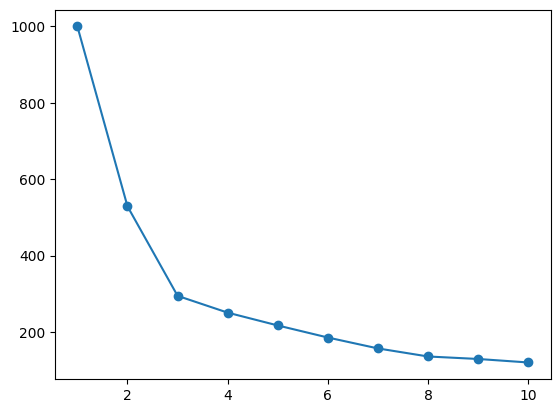

In [290]:
plt.plot(K_range, inertia, marker='o')

In [291]:
kmeans_final = KMeans(n_clusters=3, random_state=42)


In [292]:
cluster_labels = kmeans_final.fit_predict(X_scaled)


In [293]:
df['cluster'] = cluster_labels
df

,Feature_1,Feature_2,True_Cluster,cluster
0,-2.282534,-9.692815,2,1
1,-6.147668,1.755990,1,2
2,13.399091,-1.260023,1,0
3,-4.077630,3.160226,0,2
4,9.444735,0.340868,1,0
...,...,...,...,...
495,-1.282205,-3.181575,2,1
496,-2.817604,10.378894,0,2
497,3.296740,8.649256,1,0
498,-8.970519,-2.684073,2,1


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

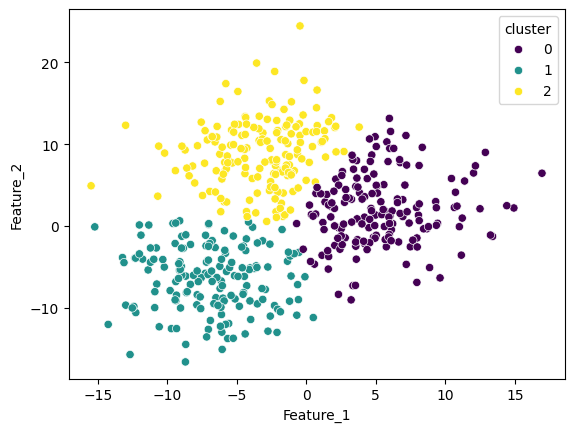

In [294]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

In [295]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

In [296]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)


In [297]:
y_true

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,

In [298]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df = df.assign(True_Cluster=y_true)
df

,Feature_1,Feature_2,True_Cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0
...,...,...,...
495,0.239754,0.985462,0
496,0.072145,0.184834,1
497,0.590273,-0.365577,1
498,1.619465,-0.283658,1


In [299]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Feature_1', 'Feature_2']])

In [300]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [301]:
df['kmeans_cluster'] = kmeans_labels


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

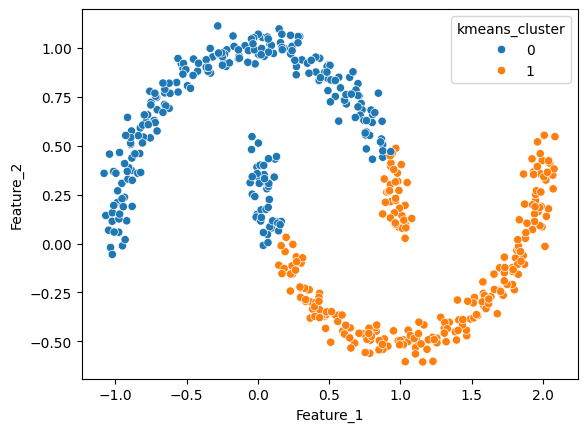

In [302]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')


In [303]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [304]:
df['dbscan_cluster'] = dbscan_labels


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

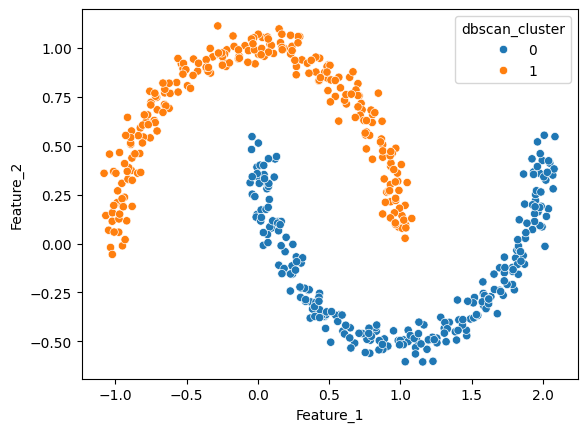

In [305]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')


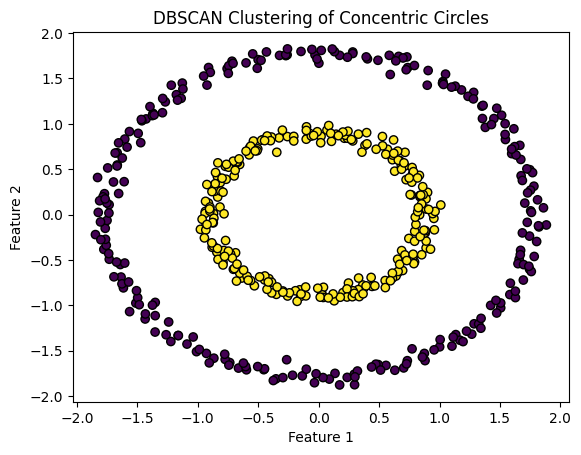

In [306]:
#create concentric circle dataset
from sklearn.datasets import make_circles
X, y_true = make_circles(n_samples=500, noise=0.03, factor=0.5, random_state=4)

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['True_Cluster'] = y_true

dbscan = DBSCAN(eps=0.3, min_samples=5)

X_scaled = scaler.fit_transform(df[['Feature_1', 'Feature_2']])

clusters_circles = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_circles, cmap='viridis',marker='o', edgecolor='k')
plt.title('DBSCAN Clustering of Concentric Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()



DBScan Visualization: https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/